In [4]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import healpix_geo
import numpy as np
import matplotlib.pyplot as plt
from cdshealpix import to_ring
import sys
sys.path.append("..")
from healpix_analyse.powerspectra import powerspectra

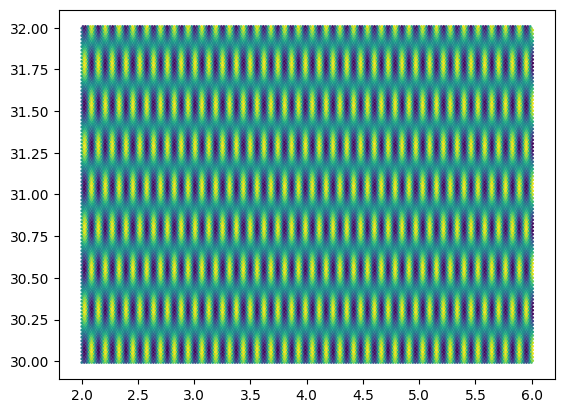

In [7]:
level = 12
ellipsoid = 'WGS84'
indexing_scheme = 'ring' # 'ring' or 'nested'
definition = 20

# Coverage box
lon_min, lon_max = 2.0, 6.0
lat_min, lat_max = 30.0, 32.0

cell_ids, _, _ = healpix_geo.nested.zone_coverage(bbox=(lon_min,lat_min,lon_max,lat_max),
                                                  depth=level, 
                                                  ellipsoid=ellipsoid)

if indexing_scheme == 'ring': 
    cell_ids = to_ring(cell_ids, depth=level)
    lon, lat = healpix_geo.ring.healpix_to_lonlat(cell_ids, level, ellipsoid=ellipsoid)
elif indexing_scheme == 'nested':
    lon, lat = healpix_geo.nested.healpix_to_lonlat(cell_ids, level, ellipsoid=ellipsoid)
else:
    raise NotImplementedError("For now, indexing_scheme must be 'ring' or 'nested'")

data = np.cos(1024*lon/definition) * np.sin(256*lat/definition) + 1

plt.scatter(lon, lat, c=data, s=1)

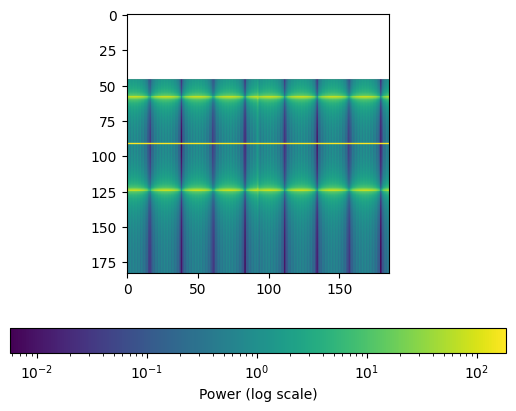

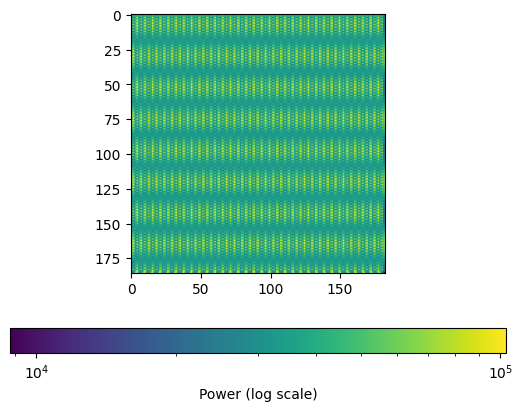

In [8]:
nu, cl = powerspectra(cell_ids, level, data, indexing_scheme=indexing_scheme, plot_2D_fft=True)

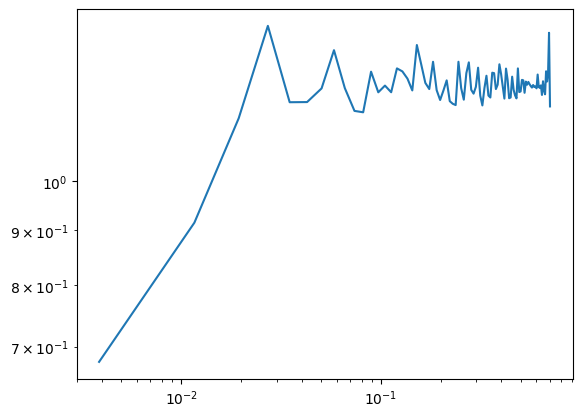

In [9]:
plt.plot(nu, cl)
plt.yscale('log')
plt.xscale('log')

In [10]:
lats = np.unique(lat)
lons = np.unique(lon)

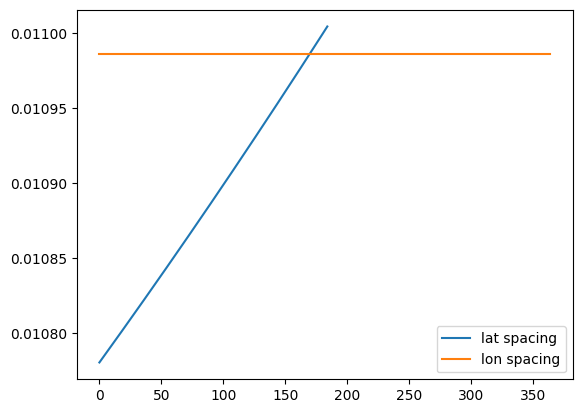

In [11]:
plt.plot(np.diff(lats), label='lat spacing')
plt.plot(np.diff(lons), label='lon spacing')
plt.legend()
plt.show()

Projecting to UTM Zone 31N...
Interpolating data onto regular grid...
Computing native spherical power spectrum...


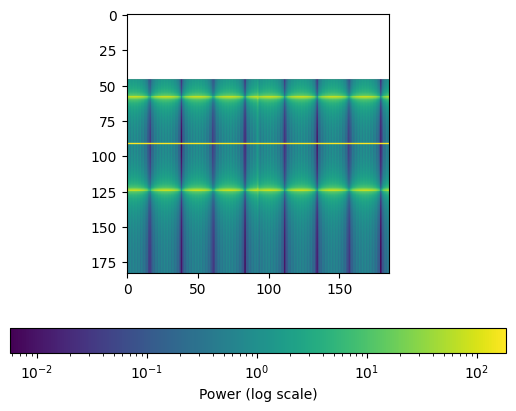

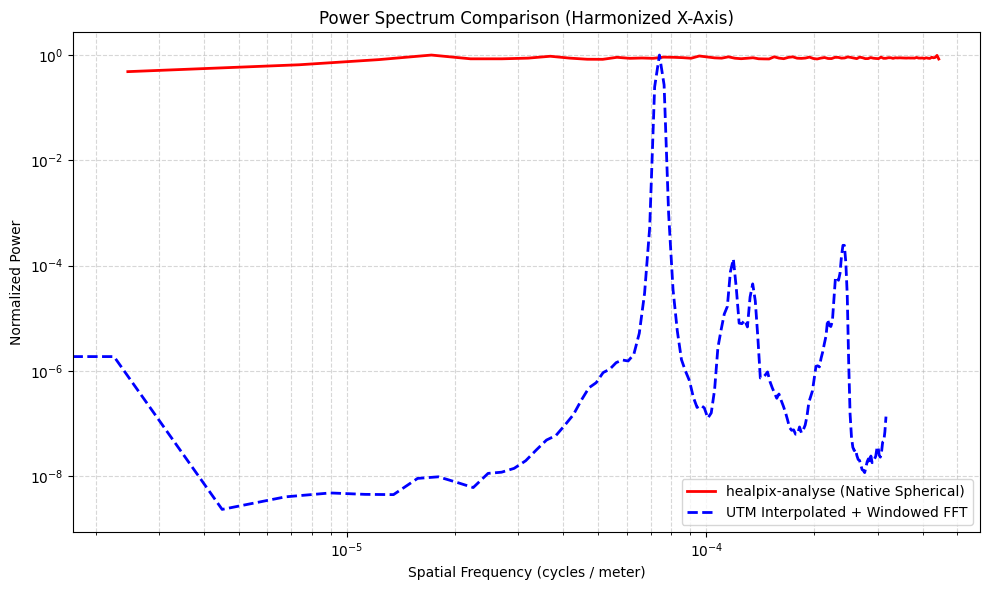

In [28]:
import pyproj
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# ==========================================
# 1. Project to UTM and Interpolate
# ==========================================
# Approximate pixel size for HEALPix level 12 is ~1580 meters
grid_resolution_meters = 1580.0  

print("Projecting to UTM Zone 31N...")
transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:32631", always_xy=True)
utm_x, utm_y = transformer.transform(lon, lat)

print("Interpolating data onto regular grid...")
xi = np.arange(utm_x.min(), utm_x.max(), grid_resolution_meters)
yi = np.arange(utm_y.min(), utm_y.max(), grid_resolution_meters)
XI, YI = np.meshgrid(xi, yi)

grid_data = griddata((utm_x, utm_y), data, (XI, YI), method='linear')

# Fill NaNs (outside the boundary) with the mean value to avoid FFT errors
mean_val = np.nanmean(grid_data)
grid_data_filled = np.nan_to_num(grid_data, nan=mean_val)

# Remove the mean to eliminate the massive spike at frequency 0
grid_data_centered = grid_data_filled - mean_val

# ==========================================
# 2. Apply 2D Windowing to prevent Spectral Leakage
# ==========================================
ny, nx = grid_data_centered.shape

# Create a 2D Hanning window that tapers the edges smoothly to zero
hy = np.hanning(ny)
hx = np.hanning(nx)
window_2d = np.outer(hy, hx)

# Multiply our centered data by the window
grid_data_windowed = grid_data_centered * window_2d

# ==========================================
# 3. Compute the Windowed 2D FFT & Radial Average
# ==========================================
fft2d_shifted = np.fft.fftshift(np.fft.fft2(grid_data_windowed))
power_spectrum_2d = np.abs(fft2d_shifted)**2

# Get radial distances from center
y_idx, x_idx = np.indices(power_spectrum_2d.shape)
center_y, center_x = ny // 2, nx // 2
radius = np.sqrt((x_idx - center_x)**2 + (y_idx - center_y)**2).astype(int)

# Bin and average
power_sum = np.bincount(radius.ravel(), power_spectrum_2d.ravel())
pixels_in_bin = np.bincount(radius.ravel())

valid_bins = pixels_in_bin > 0
power_1d_cartesian = np.zeros_like(power_sum)
power_1d_cartesian[valid_bins] = power_sum[valid_bins] / pixels_in_bin[valid_bins]

# Calculate physical Cartesian spatial frequencies (cycles per meter)
max_freq = 1.0 / (2 * grid_resolution_meters)
freqs_cartesian = np.linspace(0, max_freq, len(power_1d_cartesian))

# ==========================================
# 4. Compare with your HEALPix-Analyse script
# ==========================================
print("Computing native spherical power spectrum...")

# CRITICAL FIX: Pass dx=grid_resolution_meters here so the units match!
nu_spherical, cl_spherical = powerspectra(
    cell_ids, 
    level, 
    data, 
    indexing_scheme=indexing_scheme, 
    dx=grid_resolution_meters,  # <--- This aligns the X-axes
    plot_2D_fft=False
)

# Normalize both Y-axes so their shapes can be compared directly
# (We slice from [1:] to safely ignore any residual DC/Zero-frequency offsets)
power_1d_cart_norm = power_1d_cartesian / np.max(power_1d_cartesian[1:])
cl_spherical_norm = cl_spherical / np.max(cl_spherical[1:])

# ==========================================
# 5. Plotting
# ==========================================
plt.figure(figsize=(10, 6))

plt.plot(nu_spherical, cl_spherical_norm, 
         label="healpix-analyse (Native Spherical)", color='red', linewidth=2)

plt.plot(freqs_cartesian, power_1d_cart_norm, 
         label="UTM Interpolated + Windowed FFT", color='blue', linestyle='--', linewidth=2)

plt.title("Power Spectrum Comparison (Harmonized X-Axis)")
plt.xlabel("Spatial Frequency (cycles / meter)")
plt.ylabel("Normalized Power")

# Log scales help reveal the peak alignments and noise floors
plt.yscale('log')
plt.xscale('log')

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()